**Import pandas**

Loads the `pandas` library, which will be used to read the dataset into a DataFrame and manipulate it throughout the notebook.

In [1]:
 import pandas as pd

**Import all core libraries**

Imports everything needed for the rest of the workflow in one place:
- `pandas`, `numpy` — data handling
- `LabelEncoder`, `StandardScaler` — encoding the target and scaling features
- `train_test_split` — splitting data into train/test sets
- `LogisticRegression`, `DecisionTreeClassifier`, `RandomForestClassifier` — the three candidate models
- `accuracy_score`, `classification_report`, `confusion_matrix` — evaluation metrics

In [22]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**Load the dataset**

Reads the heart disease CSV file from the Kaggle input path into a DataFrame `df` and displays it, so you can see the raw columns and a few sample rows.

In [3]:
df = pd.read_csv('/kaggle/input/datasets/dhruvgutpa/predicting-heart-disease/train (2).csv')
df

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,629995,56,0,1,110,226,0,0,132,0,0.0,1,0,7,Absence
629996,629996,54,1,4,128,249,1,2,150,0,0.0,2,0,3,Absence
629997,629997,67,1,4,130,275,0,0,149,0,0.0,1,2,7,Presence
629998,629998,52,1,4,140,199,0,2,157,0,0.0,1,0,6,Presence


**Check dataset shape**

Prints `(rows, columns)` — a quick sanity check on how many patient records and features the dataset contains.

In [4]:
df.shape

(630000, 15)

**Inspect DataFrame info**

Intended to show column names, non-null counts, and data types via `df.info()`. ⚠️ Note: the parentheses are missing (`df.info` instead of `df.info()`), so this only prints a reference to the method rather than actually running it — it won't display the summary table.

In [5]:
df.info

<bound method DataFrame.info of             id  Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  \
0            0   58    1                4  152          239             0   
1            1   52    1                1  125          325             0   
2            2   56    0                2  160          188             0   
3            3   44    0                3  134          229             0   
4            4   58    1                4  140          234             0   
...        ...  ...  ...              ...  ...          ...           ...   
629995  629995   56    0                1  110          226             0   
629996  629996   54    1                4  128          249             1   
629997  629997   67    1                4  130          275             0   
629998  629998   52    1                4  140          199             0   
629999  629999   51    0                2  130          199             0   

        EKG results  Max HR  Exercise angin

**Summary statistics**

`df.describe()` prints count, mean, std, min, max, and quartiles for every numeric column — useful for spotting outliers or unexpected ranges (e.g. cholesterol or blood pressure values that look impossible).

In [7]:
df.describe()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,54.136706,0.714735,3.312752,130.497433,245.011814,0.079987,0.981660,152.816763,0.273725,0.716028,1.455871,0.451040,4.618873
std,181865.479132,8.256301,0.451541,0.851615,14.975802,33.681581,0.271274,0.998783,19.112927,0.445870,0.948472,0.545192,0.798549,1.950007
min,0.000000,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,157499.750000,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,314999.500000,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.000000,3.000000
75%,472499.250000,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000
max,629999.000000,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


**Check column data types**

Prints the dtype of every column (`int64`, `float64`, `object`, etc.), which matters for knowing which columns need encoding before modeling.

In [10]:
print(df.dtypes)

id                           int64
Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
Heart Disease               object
dtype: object


**Inspect target classes**

Prints the unique values in the `Heart Disease` column (the target/label). This confirms it's a binary classification problem — typically `'Presence'` and `'Absence'`.

In [14]:
print(df["Heart Disease"].unique())

['Presence' 'Absence']


**Check for missing values**

`df.isnull().sum()` counts missing (NaN) values per column. If all columns show 0, the dataset is complete and no imputation is needed.

In [8]:
df.isnull().sum()

id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

**Re-import splitting/encoding tools**

Re-imports `train_test_split` and `LabelEncoder` (already imported in cell 1). This is redundant but harmless — likely leftover from iterative notebook editing.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

**Separate features and target**

Builds the feature matrix `X` by dropping the `Heart Disease` (target) and `id` (identifier, not predictive) columns from `df`. `y` is set to the `Heart Disease` column — what the models will try to predict.

In [15]:
X = df.drop(columns=['Heart Disease', 'id']) 
y = df['Heart Disease']

**Train/test split**

Splits `X` and `y` into training and test sets: 80% for training, 20% held out for testing (`test_size=0.2`), with `random_state=4` for reproducibility.

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=4)

**Re-import model classes**

Re-imports `LogisticRegression`, `DecisionTreeClassifier`, and `RandomForestClassifier` (already imported in cell 1) — again redundant but harmless.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

**Instantiate the three candidate models**

Creates untrained instances of Logistic Regression, Decision Tree, and Random Forest so their performance can be compared later. (Note: `log_reg` here gets overwritten with a differently-configured version in the next cell.)

In [18]:
log_reg = LogisticRegression(max_iter=1000)
dec_tree = DecisionTreeClassifier(random_state=42)
rand_forest = RandomForestClassifier(random_state=42, n_jobs=-1)

**Scale features and train Logistic Regression**

This cell does two things:
1. Fits a `StandardScaler` on `X_train` and uses it to scale both `X_train` and `X_test` (`X_train_scaled`, `X_test_scaled`) — Logistic Regression is sensitive to feature scale, so this step is required for it to perform well.
2. Creates a new `LogisticRegression` (max_iter=5000, solver='lbfgs') and trains it on the **scaled** training data. This replaces the `log_reg` instance created in the previous cell.

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=5000,
    solver="lbfgs",
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=5000, random_state=42)

**Train the Decision Tree**

Fits `dec_tree` directly on the **unscaled** `X_train`/`y_train`. Tree-based models split on feature thresholds, so they don't require feature scaling.

In [23]:
print("Training Decision Tree...")
dec_tree.fit(X_train, y_train)


Training Decision Tree...


DecisionTreeClassifier(random_state=42)

**Train the Random Forest**

Fits `rand_forest` on the unscaled training data, same reasoning as the Decision Tree — tree ensembles don't need scaled inputs.

In [24]:
print("Training Random Forest...")
rand_forest.fit(X_train, y_train)

Training Random Forest...


RandomForestClassifier(n_jobs=-1, random_state=42)

**Import evaluation metrics**

Imports `accuracy_score`, `precision_score`, `f1_score`, and `confusion_matrix` for evaluating the three trained models.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix

**Generate predictions on the test set**

Runs each trained model on its respective test data: Logistic Regression uses `X_test_scaled` (since it was trained on scaled data), while the Decision Tree and Random Forest use the raw `X_test`.

In [26]:
log_pred = log_reg.predict(X_test_scaled)
dt_pred = dec_tree.predict(X_test)
rf_pred = rand_forest.predict(X_test)


**Compare accuracy across models**

Prints the accuracy score for each of the three models side by side, giving a first-pass comparison of which performs best on the held-out test set.

In [31]:
print("\nAccuracy Scores")
 

print("Logistic Regression :", accuracy_score(y_test, log_pred))
print("Decision Tree       :", accuracy_score(y_test, dt_pred))
print("Random Forest       :", accuracy_score(y_test, rf_pred))


Accuracy Scores
Logistic Regression : 0.8845079365079365
Decision Tree       : 0.8259126984126984
Random Forest       : 0.8814444444444445


**Detailed classification reports**

Prints precision, recall, F1-score, and support for each class, for all three models — a more nuanced view than accuracy alone, especially useful if the classes are imbalanced.

In [30]:
print("\n Logistic Regression ")
print(classification_report(y_test, log_pred))

print("\n  Decision Tree  ")
print(classification_report(y_test, dt_pred))

print("\n Random Forest ")
print(classification_report(y_test, rf_pred))


 Logistic Regression 
              precision    recall  f1-score   support

     Absence       0.89      0.90      0.90     69490
    Presence       0.88      0.86      0.87     56510

    accuracy                           0.88    126000
   macro avg       0.88      0.88      0.88    126000
weighted avg       0.88      0.88      0.88    126000


  Decision Tree  
              precision    recall  f1-score   support

     Absence       0.84      0.84      0.84     69490
    Presence       0.80      0.81      0.81     56510

    accuracy                           0.83    126000
   macro avg       0.82      0.82      0.82    126000
weighted avg       0.83      0.83      0.83    126000


 Random Forest 
              precision    recall  f1-score   support

     Absence       0.89      0.90      0.89     69490
    Presence       0.87      0.86      0.87     56510

    accuracy                           0.88    126000
   macro avg       0.88      0.88      0.88    126000
weighted avg   

**Confusion matrices (text)**

Prints the raw confusion matrix (true positives/negatives, false positives/negatives) for each model, showing exactly what kinds of mistakes each one makes.

In [29]:
print("\nLogistic Regression Confusion Matrix")
print(confusion_matrix(y_test, log_pred))

print("\nDecision Tree Confusion Matrix")
print(confusion_matrix(y_test, dt_pred))

print("\nRandom Forest Confusion Matrix")
print(confusion_matrix(y_test, rf_pred))


Logistic Regression Confusion Matrix
[[62880  6610]
 [ 7942 48568]]

Decision Tree Confusion Matrix
[[58312 11178]
 [10757 45753]]

Random Forest Confusion Matrix
[[62405  7085]
 [ 7853 48657]]


**Plot target class distribution**

A bar chart of how many patients fall into each `Heart Disease` class — checks whether the dataset is balanced or skewed toward one outcome.

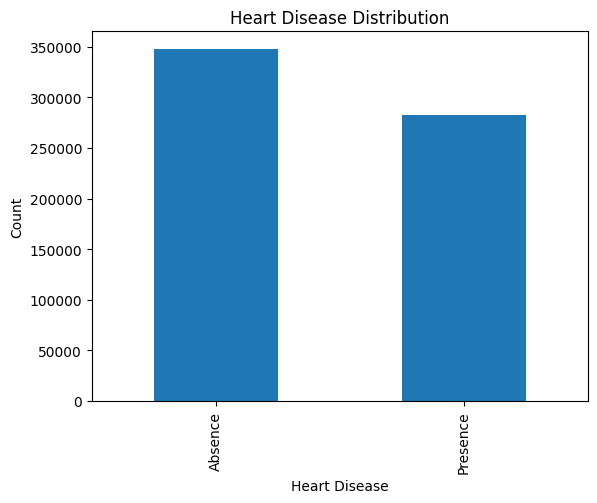

In [32]:
import matplotlib.pyplot as plt

df["Heart Disease"].value_counts().plot(kind="bar")

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

**Plot age distribution**

A histogram of the `Age` column (20 bins) to visualize how patient ages are distributed across the dataset.

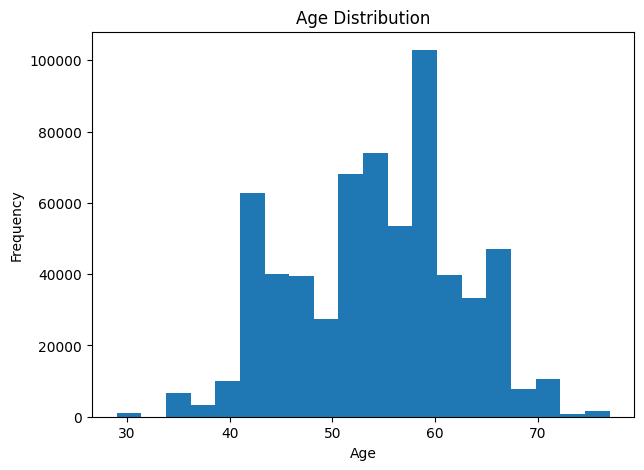

In [33]:
plt.figure(figsize=(7,5))

plt.hist(df["Age"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

**Encode the target column**

Fits a `LabelEncoder` (`le`) on the `Heart Disease` column and overwrites it with numeric labels (e.g. `Absence` → 0, `Presence` → 1). This encoder is the same one later saved as `label_encoder.pkl`. Note this happens *after* the original train/test split, so `X_train`/`X_test`/`y_train`/`y_test` created earlier still reference the original string labels.

In [37]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Heart Disease"] = le.fit_transform(df["Heart Disease"])

**Correlation heatmap**

Plots a heatmap of pairwise correlations between all numeric columns (now including the newly encoded numeric target), helping identify which features are most linearly associated with heart disease.

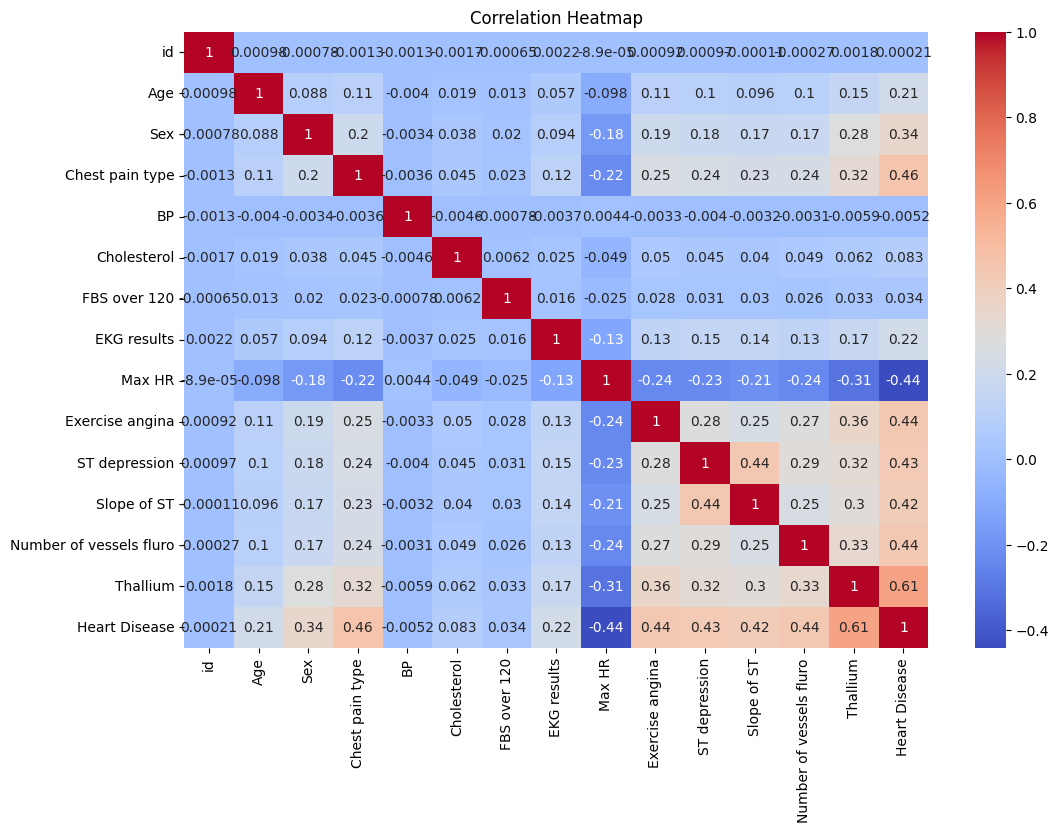

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**Cholesterol boxplot**

Visualizes the spread and potential outliers in the `Cholesterol` column using a boxplot.

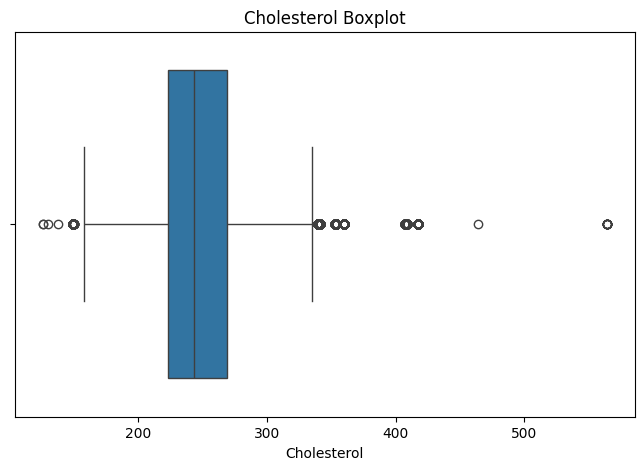

In [41]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Cholesterol"])

plt.title("Cholesterol Boxplot")
plt.show()

**Visual confusion matrix (Logistic Regression)**

Uses `ConfusionMatrixDisplay` to plot the Logistic Regression's confusion matrix as a heatmap-style graphic, easier to read at a glance than the printed matrix from cell 21.

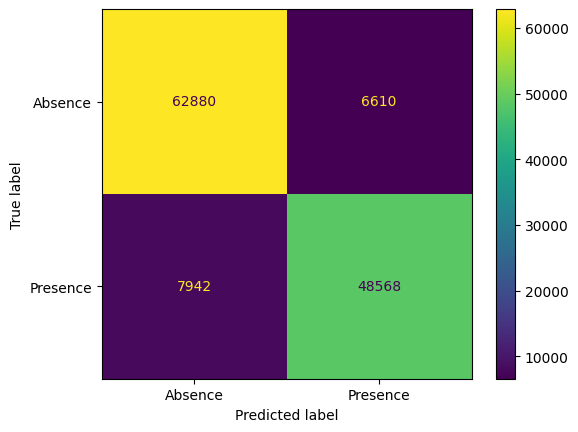

In [42]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    log_pred
)

plt.show()

**Random Forest feature importance**

Extracts `feature_importances_` from the trained Random Forest, sorts features from most to least important, and plots them as a horizontal bar chart — shows which clinical measurements the model relies on most.

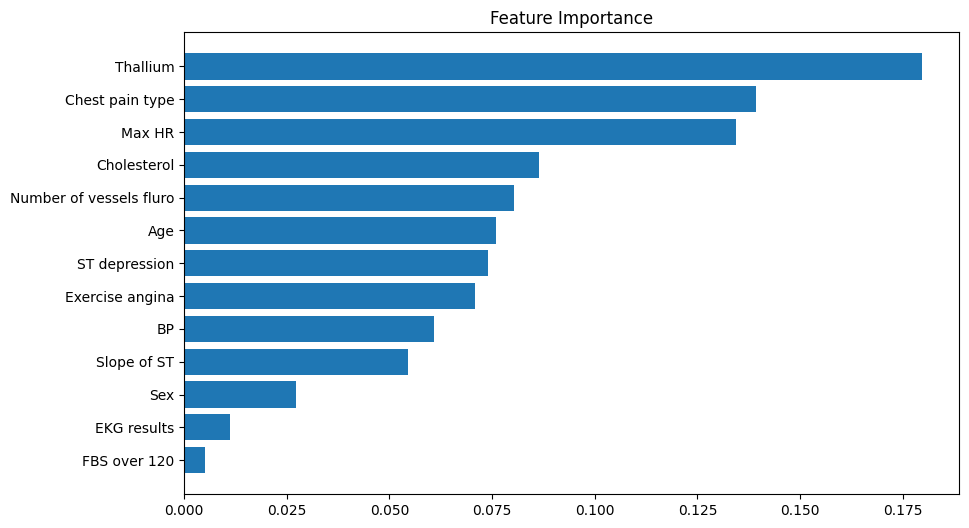

In [43]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rand_forest.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")
plt.gca().invert_yaxis()

plt.show()

**Manual accuracy comparison chart**

Plots a bar chart comparing the three models using hardcoded accuracy values (0.8845, 0.8259, 0.8814), presumably copied from the earlier printed results in cell 19, for a clean visual summary.

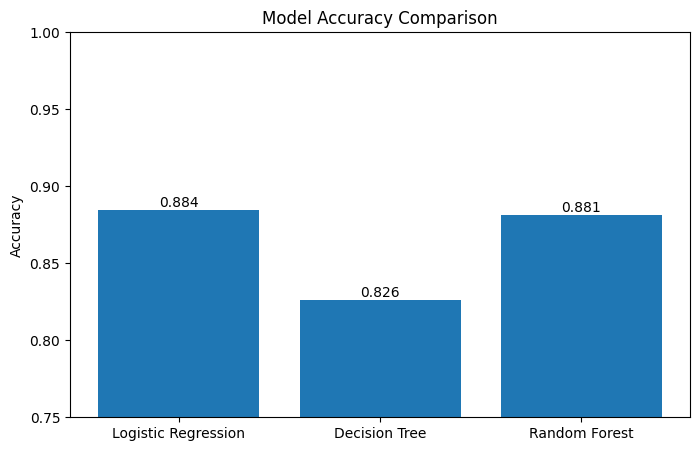

In [44]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Decision Tree", "Random Forest"]
accuracy = [0.8845, 0.8259, 0.8814]

plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.75, 1.0)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom"
    )

plt.show()

**Save trained artifacts to disk**

Uses `joblib` to serialize and save the trained Logistic Regression model, the fitted `StandardScaler`, and the `LabelEncoder` as `.pkl` files — these are the exact three files the Streamlit app (`app.py`) loads to make predictions.

In [45]:
import joblib

# Save the model
joblib.dump(log_reg, "heart_disease_model.pkl")

# Save the scaler (required for Logistic Regression)
joblib.dump(scaler, "scaler.pkl")

# Save the label encoder
joblib.dump(le, "label_encoder.pkl")

print("All files saved successfully!")

All files saved successfully!


**Confirm saved files**

Lists the contents of the working directory to verify the `.pkl` files were written successfully.

In [46]:
import os

print(os.listdir("/kaggle/working"))

['label_encoder.pkl', 'scaler.pkl', '.virtual_documents', 'heart_disease_model.pkl']


**Check the scaler's expected feature order**

Prints `scaler.feature_names_in_` — the exact column names and order the scaler (and therefore the model) expects. This is critical: any app using these `.pkl` files must feed features in this exact order.

In [47]:
 print(scaler.feature_names_in_)

['Age' 'Sex' 'Chest pain type' 'BP' 'Cholesterol' 'FBS over 120'
 'EKG results' 'Max HR' 'Exercise angina' 'ST depression' 'Slope of ST'
 'Number of vessels fluro' 'Thallium']


**Rebuild the feature set**

Re-creates `X` from `df` (dropping `id` and `Heart Disease`) after the target was label-encoded in cell 24 — likely a cleanup/re-run step before the final retraining below.

In [49]:
X = df.drop(["id", "Heart Disease"], axis=1)

**Refit the scaler**

Calls `scaler.fit(X_train)` again — recomputes the scaler's mean/scale statistics on `X_train`. Note this only fits (no `.transform()` here), so it doesn't produce a new scaled array in this cell.

In [50]:
scaler.fit(X_train)

StandardScaler()

**Retrain Logistic Regression (final pass)**

Retrains `log_reg` on `X_train_scaled`/`y_train` again. Combined with cells 33–38, this looks like a final cleanup/re-run pass to make sure the model, scaler, and encoder are all in sync before the last save.

In [51]:
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=5000, random_state=42)

**Re-save model and scaler**

Saves the (re-trained) `log_reg` and `scaler` to `heart_disease_model.pkl` and `scaler.pkl` again, overwriting the earlier versions from cell 30.

In [52]:
joblib.dump(log_reg,"heart_disease_model.pkl")
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

**Rebuild X and y**

Re-derives `X` (features) and `y` (now-numeric target) from `df` one more time, post-encoding — ensures both are consistent with the final label-encoded target before the last save.

In [54]:
 X = df.drop(["id", "Heart Disease"], axis=1)
y = df["Heart Disease"]

**Final save of all three artifacts**

Saves the model, scaler, and label encoder one final time — this is the version most likely to be the one actually shipped/used, since it's the last save in the notebook. Prints a confirmation message once done.

In [55]:
import joblib

# Save the model
joblib.dump(log_reg, "heart_disease_model.pkl")

# Save the scaler (required for Logistic Regression)
joblib.dump(scaler, "scaler.pkl")

# Save the label encoder
joblib.dump(le, "label_encoder.pkl")

print("All files saved successfully!")

All files saved successfully!


**(Empty cell)**

No code — likely a trailing cell left over from editing.